# Preprocessing & Exploratory Data Analysis (EDA)
## Dataset: Employee Burnout Level Prediction

Notebook ini difungsikan untuk memahami dataset, memeriksa kualitas data, melakukan pengecekan visual, dan membuat file referensi `dataset_preprocessed.csv`.

---

1. **Data Preprocessing**: membersihkan dan menyiapkan data mentah agar layak digunakan model.
2. **Exploratory Data Analysis (EDA)**: memahami karakteristik, distribusi, dan pola data melalui statistik deskriptif dan visualisasi.

**Tentang Dataset:**  
Dataset berisi observasi **7.000 karyawan** dengan atribut pekerjaan dan gaya hidup. Target prediksi adalah `burnout_level` (Low / Medium / High).

| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia karyawan (tahun) |
| `experience_years` | Numerik | Lama pengalaman kerja |
| `daily_work_hours` | Numerik | Jam kerja per hari |
| `sleep_hours` | Numerik | Jam tidur per hari |
| `caffeine_intake` | Numerik | Konsumsi kafein per hari |
| `bugs_per_day` | Numerik | Jumlah bug yang dikerjakan per hari |
| `commits_per_day` | Numerik | Jumlah commit per hari |
| `meetings_per_day` | Numerik | Jumlah meeting per hari |
| `screen_time` | Numerik | Waktu di depan layar (jam) |
| `exercise_hours` | Numerik | Durasi olahraga (jam) |
| `stress_level` | Numerik | Tingkat stres (skala 0–100) |
| `burnout_level` | Kategorik | **Target**: Low / Medium / High |

Note: notebook modeling final tetap menggunakan `dataset.csv` mentah dan imputasi dilakukan di dalam pipeline model agar tidak terjadi data leakage. 

Jadi, file `dataset_preprocessed.csv` di sini lebih berfungsi sebagai insight, dokumentasi dan referensi hasil preprocessing, bukan sebagai dataset yang menjadisumber training.

Alur notebook:
1. Import library dan load dataset.
2. Cek struktur data.
3. Cek missing value dan duplikasi.
4. Cek distribusi fitur numerik dan target.
5. Cek outlier.
6. Menganalisis korelasi dan bivariat.
7. Membuat CSV preprocessing referensi.
8. Menyimpulkan insight dari hasil EDA.

## 1. Import Library

Library yang digunakan:
- **pandas** dan **numpy** untuk manipulasi data tabular.
- **matplotlib** dan **seaborn** untuk visualisasi.
- `display()` digunakan supaya tabel lebih mudah dibaca di notebook.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.Set2.colors)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
LABEL_ORDER = ["Low", "Medium", "High"]
LABEL_MAP = {"Low": 0, "Medium": 1, "High": 2}
TARGET_COL = "burnout_level"

# Fitur stress_level sengaja tidak dipakai di final model karena terlalu dekat secara konsep dengan label burnout
# Tetapi kolom stress_level tetap dianalisis di tahap EDA agar proses eksplorasi tetap transparan
DROPPED_FOR_MODEL = ["stress_level"]

## 2. Load Dataset

Mengecek dataset asli `dataset.csv`, kita ingin melihat ukuran dataset, beberapa baris awal, tipe data, dan statistik deskriptif untuk memahami kondisi awal data.

In [34]:
df = pd.read_csv("dataset.csv")

print(f"Shape dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
display(df.head())

Shape dataset: 7,000 baris x 12 kolom


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [35]:
print("Informasi tipe data dan non-null count:")
df.info()

Informasi tipe data dan non-null count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [36]:
print("Statistik deskriptif fitur numerik:")
display(df.describe().T)

Statistik deskriptif fitur numerik:


,count,mean,std,min,25%,50%,75%,max
age,6860.0,32.129446,7.230254,20.00,26.0000,32.000,38.0000,44.00
experience_years,6860.0,9.581050,5.760972,0.00,5.0000,10.000,15.0000,19.00
daily_work_hours,6860.0,9.000277,2.863944,4.00,6.5600,8.990,11.4225,14.00
sleep_hours,6860.0,6.485638,1.445008,4.00,5.2200,6.460,7.7400,9.00
caffeine_intake,6860.0,3.540671,2.283445,0.00,2.0000,4.000,6.0000,7.00
bugs_per_day,6860.0,9.482653,5.751664,0.00,5.0000,9.000,14.0000,19.00
commits_per_day,6860.0,14.458455,8.669846,0.00,7.0000,14.000,22.0000,29.00
meetings_per_day,6860.0,4.545044,2.856766,0.00,2.0000,5.000,7.0000,9.00
screen_time,6860.0,11.974773,3.091204,5.21,9.4600,12.020,14.4225,18.93
exercise_hours,6860.0,1.007611,0.576708,0.00,0.5100,1.020,1.5100,2.00


## 3. Cek kualitas data

Mengecek kualitas data dari aspek:
- jumlah missing value,
- persentase missing value,
- jumlah nilai unik,
- jumlah data duplikat.

Pengecekan ini penting karena missing value dan duplikat bisa mempengaruhi hasil training model.

In [37]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})

display(quality_summary)
print("Duplicated rows:", df.duplicated().sum())

,dtype,missing_count,missing_pct,unique_values
age,float64,140,2.0,25
experience_years,float64,140,2.0,20
daily_work_hours,float64,140,2.0,999
sleep_hours,float64,140,2.0,501
caffeine_intake,float64,140,2.0,8
bugs_per_day,float64,140,2.0,20
commits_per_day,float64,140,2.0,30
meetings_per_day,float64,140,2.0,10
screen_time,float64,140,2.0,1279
exercise_hours,float64,140,2.0,201


Duplicated rows: 0


### Visualisasi Missing Values

Untuk mengecek kolom mana yang paling banyak memiliki missing value. Jika missing value besar, menghapus baris yang missing value bisa membuat banyak informasi lain hilang, sehingga strategi imputasi akan ditimbang dari hasil ini.

,missing count,missing (%)
age,140,2.0
experience_years,140,2.0
daily_work_hours,140,2.0
sleep_hours,140,2.0
caffeine_intake,140,2.0
bugs_per_day,140,2.0
commits_per_day,140,2.0
meetings_per_day,140,2.0
screen_time,140,2.0
exercise_hours,140,2.0


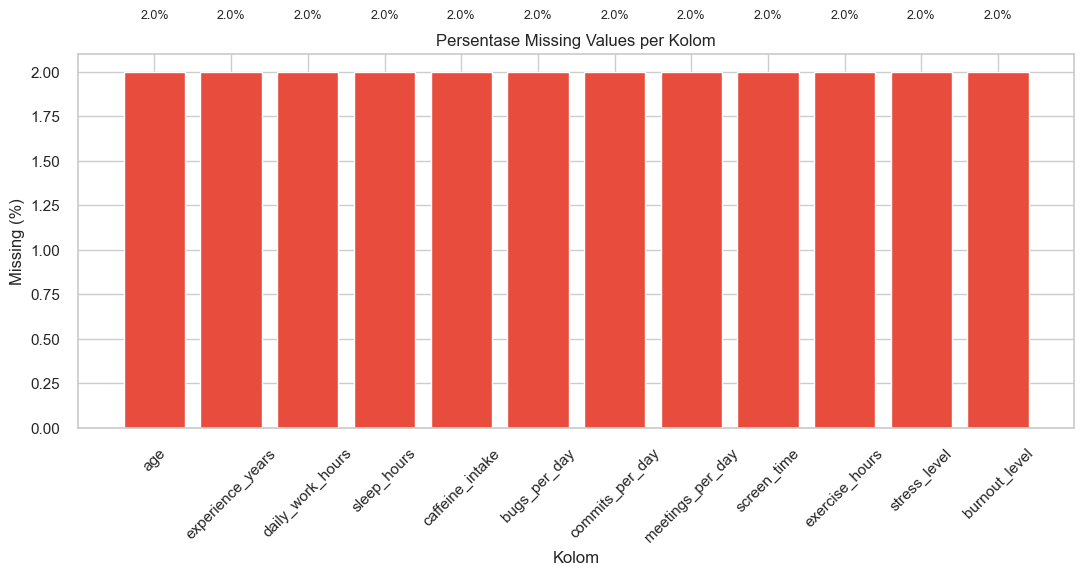

In [38]:
missing_pct = df.isna().mean().mul(100).round(2)
missing_count = df.isna().sum()
missing_df = pd.DataFrame({"missing count": missing_count, "missing (%)": missing_pct})

display(missing_df)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ["#e74c3c" if pct > 0 else "#95a5a6" for pct in missing_pct]
ax.bar(missing_pct.index.astype(str), missing_pct.values, color=bar_colors)
ax.set_title("Persentase Missing Values per Kolom")
ax.set_ylabel("Missing (%)")
ax.set_xlabel("Kolom")
ax.tick_params(axis="x", rotation=45)

for i, pct in enumerate(missing_pct.values):
    if pct > 0:
        ax.text(i, pct + 0.3, f"{pct:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
missing_rows = df[df.isna().any(axis=1)]
all_same = missing_rows.isnull().all(axis=1).all()
print(f"Jumlah baris yang memiliki minimal satu missing value: {len(missing_rows):,}")
print(f"Semua kolom missing di baris yang sama: {all_same}")
print(f"Persentase baris yang memiliki missing value: {len(missing_rows) / len(df) * 100:.2f}%")

if len(missing_rows) > 0:
    display(missing_rows.head())

Jumlah baris yang memiliki minimal satu missing value: 1,510
Semua kolom missing di baris yang sama: False
Persentase baris yang memiliki missing value: 21.57%


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
6,26.0,NaN,6.53,7.60,6.0,4.0,11.0,9.0,9.38,0.54,39.09,Medium
12,NaN,12.0,13.90,7.75,6.0,18.0,10.0,9.0,16.08,1.43,100.00,High
32,35.0,15.0,6.88,8.53,7.0,14.0,NaN,2.0,11.19,1.53,30.34,Low


### Keputusan dari hasil pengecekan Missing Values

Karena `burnout_level` adalah label/ground truth kita, baris yang `burnout_level` nya kosong tidak boleh diisi secara sintetis. Mengimputasi label bisa menyebabkan jawaban palsu dan evaluasi model menjadi kurang valid. 

Juga insight bahwa tidak semua missing values ada di satu row yang sama dan juga persentasenya cukup besar yaitu 21.57% dari total dataset. Untuk menghindari kerugian kehilangan full 1.510 rows data, kami mengimpute data numerik.

Untuk fitur numerik, kami akan menghandle missing values dengan menggunakan imputasi median. Kami menggunakan median karena lebih robust terhadap outlier dibanding mean. Pada notebook modeling, imputasi ini dilakukan di dalam pipeline agar nilai median hanya dipelajari dari data training pada setiap fold cross-validation. (tidak dilakukan di sini, mohon cek notebook `model.ipynb`)

## 4. Cek Data Duplikat

Data yang banyak terduplikat dapat membuat model terlihat lebih bagus dari kondisi aslinya karena informasi yang sama persis muncul lebih daris sekali. Karena itu, jumlah duplikasi dicek sebelum lanjut ke analisis distribusi dan untuk menghindari kejadian duplikat setelah proses imputasi nantinya.

In [40]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")

if n_dup > 0:
    display(df[df.duplicated()].head())
else:
    print("Tidak ada baris duplikat yang terdeteksi.")

Jumlah baris duplikat: 0
Tidak ada baris duplikat yang terdeteksi.


## 5. Distribusi Kelas Target (`burnout_level`)

Target terdiri dari tiga kelas, yaitu: **Low**, **Medium**, dan **High**. Distribusi target perlu dilihat karena class imbalance dapat membuat model bias ke arah kelas mayoritas dan cenderung mengabaikan kelas minoritas, juga akan memengaruhi metrik evaluasi yang cocok untuk mengevaluasi hasil prediksi nanti.

,count
burnout_level,
Low,1593
Medium,3485
High,1782
NaN,140


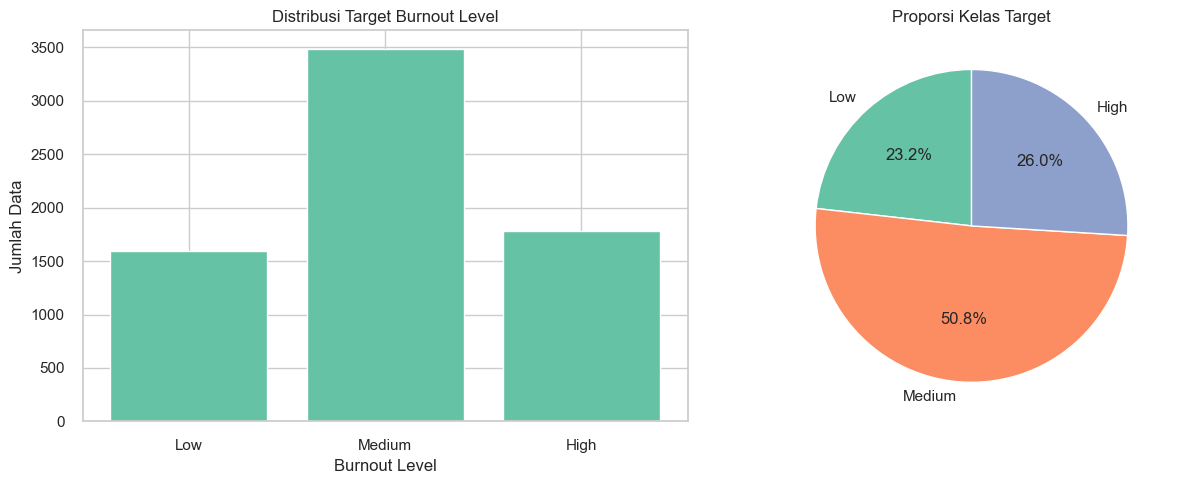

In [41]:
target_counts = df[TARGET_COL].value_counts(dropna=False).reindex(LABEL_ORDER + [np.nan])
target_counts = target_counts.dropna()
display(target_counts.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts_for_bar = df[TARGET_COL].value_counts().reindex(LABEL_ORDER)
axes[0].bar(counts_for_bar.index, counts_for_bar.values)
axes[0].set_title("Distribusi Target Burnout Level")
axes[0].set_xlabel("Burnout Level")
axes[0].set_ylabel("Jumlah Data")

counts_for_pie = df[TARGET_COL].value_counts().reindex(LABEL_ORDER)
axes[1].pie(counts_for_pie.values, labels=counts_for_pie.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporsi Kelas Target")

plt.tight_layout()
plt.show()

### Insight Distribusi Target

Dari distribusi target, kita dapat insight bahwa kelas target antara **Low**, **Medium**, dan **High** tidak seimbang dan cenderung didominasi oleh kelas Medium. Meskipun imbalance nya tidak ekstrim, kami menggunakan **F1 Macro** dibanding accuraacy biasa pada modeling nanti sebagai metrik utama karena **F1 Macro** memberikan keadilan bobot pada kelas yang lebih kecil (unweighted mean).

## 6. Distribusi Fitur Numerik

Analisis distribusi fitur numerik ini berfungsi untuk melihat pola data, kemungkinan skewness (kemiringan distribusi), dan rentang nilai data (apakah mendekati bentuk normal) untuk membantu menentukan strategi preprocessing pada modeling seperti scaling dan imputasi yang dibutuhkan.

Ringkasan Skewness & Kurtosis:
                  Skewness  Kurtosis Distribusi
age                 -0.025    -1.212   Simetris
experience_years    -0.033    -1.212   Simetris
daily_work_hours     0.011    -1.180   Simetris
sleep_hours          0.026    -1.214   Simetris
caffeine_intake     -0.025    -1.235   Simetris
bugs_per_day         0.019    -1.197   Simetris
commits_per_day     -0.002    -1.220   Simetris
meetings_per_day    -0.024    -1.214   Simetris
screen_time         -0.012    -0.902   Simetris
exercise_hours      -0.029    -1.190   Simetris
stress_level        -0.062    -0.603   Simetris


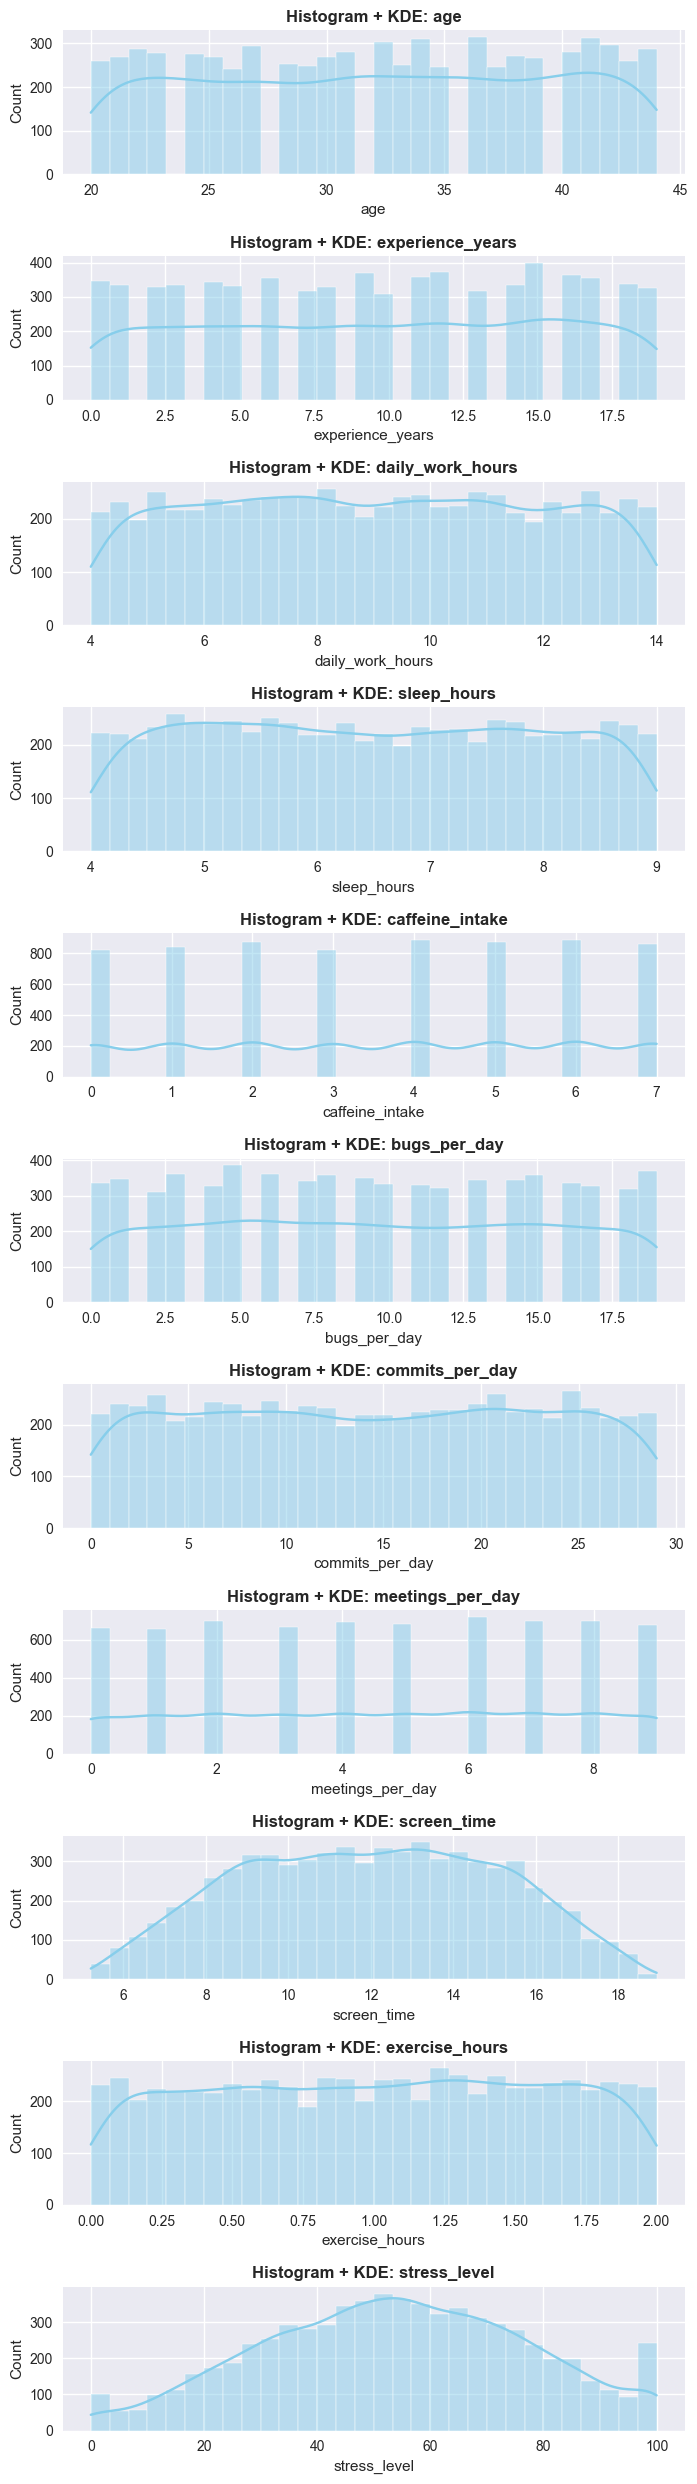

In [42]:
# Ringkasan skewness dan kurtosis
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
skewness = df[numeric_cols].skew().round(3)
kurtosis = df[numeric_cols].kurt().round(3)
summary  = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
summary['Distribusi'] = summary['Skewness'].apply(
    lambda x: 'Simetris' if abs(x) < 0.5 else ('Right-skewed' if x > 0 else 'Left-skewed')
)
print("Ringkasan Skewness & Kurtosis:")
print(summary.to_string())
plt.style.use('seaborn-v0_8')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (14, 10)


fig = plt.figure(figsize=(20, 25))

for i, col in enumerate(numeric_cols, 1):
    # Histogram + KDE
    plt.subplot(len(numeric_cols), 3, 3*(i-1) + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram + KDE: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

### Insight Distribusi Fitur Numerik

Visualisasi histogram membantu melihat apakah data cenderung normal, miring ke kanan/kiri, atau memiliki nilai ekstrem. 

**Temuan:**
- Sebagian besar fitur memiliki skewness < 0.5 sehingga distribusi nya cukup simetris
- `meetings_per_day` dan `caffeine_intake` terlihat lebih flat/uniform (data merata tanpa puncak jelas)
- `stress_level` mendekati distribusi normal

Karena beberapa model seperti Logistic Regression, SVM, dan KNN sensitif terhadap skala fitur, fitur numerik nantinya akan distandardisasi menggunakan `StandardScaler` di dalam pipeline model.

## 7. Deteksi Outlier

Outlier adalah nilai yang jauh dari mayoritas data. Outlier tidak selalu salah, tetapi dapat mengganggu model tertentu, terutama model berbasis jarak seperti KNN atau model linear yang sensitif terhadap skala seperti KNN, SVM, dan Logistic Regression.

Metode yang digunakan adalah IQR:
$$\text{Lower bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper bound} = Q3 + 1.5 \times IQR$$

Nilai di luar range tersebut dikategorikan sebagai outlier.

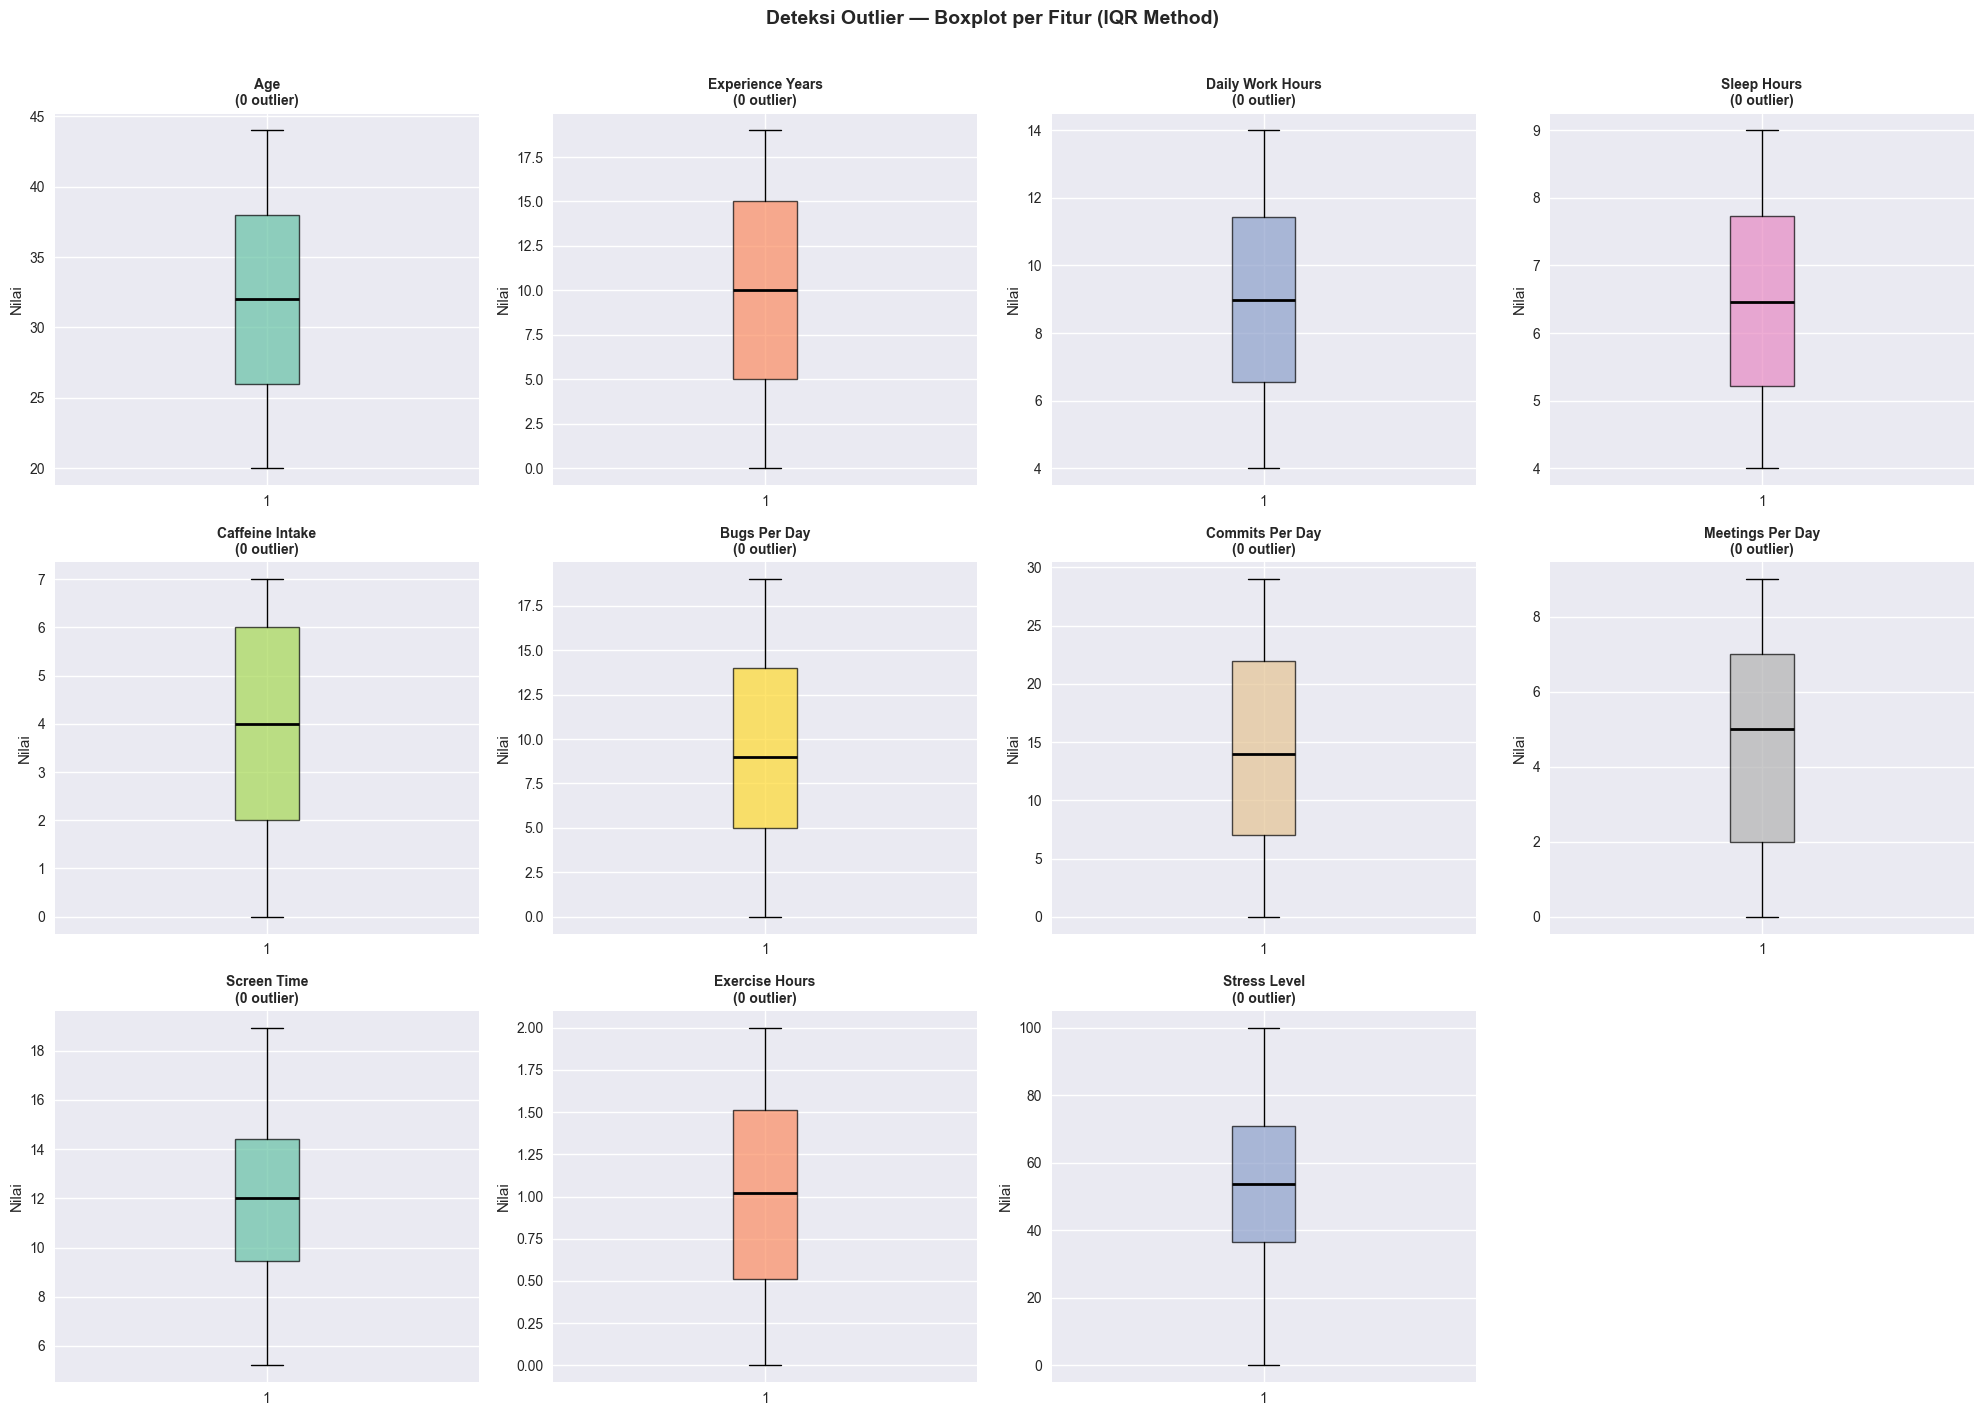

Ringkasan Outlier:
                     Q1     Q3    IQR  N Outlier  Outlier (%)
Fitur                                                        
age               26.00  38.00  12.00          0          0.0
experience_years   5.00  15.00  10.00          0          0.0
daily_work_hours   6.56  11.42   4.86          0          0.0
sleep_hours        5.22   7.74   2.52          0          0.0
caffeine_intake    2.00   6.00   4.00          0          0.0
bugs_per_day       5.00  14.00   9.00          0          0.0
commits_per_day    7.00  22.00  15.00          0          0.0
meetings_per_day   2.00   7.00   5.00          0          0.0
screen_time        9.46  14.42   4.96          0          0.0
exercise_hours     0.51   1.51   1.00          0          0.0
stress_level      36.59  70.80  34.21          0          0.0


In [43]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
palette  = sns.color_palette('Set2', len(num_cols))

outlier_summary = []
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=palette[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                    markerfacecolor='red'))
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Fitur': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                             'IQR': round(IQR,2), 'N Outlier': n_out,
                             'Outlier (%)': round(n_out/len(df)*100, 2)})
    axes[i].set_title(f"{col.replace('_',' ').title()}\n({n_out} outlier)",
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier — Boxplot per Fitur (IQR Method)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_summary).set_index('Fitur')
print("Ringkasan Outlier:")
print(outlier_df.to_string())

### Insight Outlier

Tidak ada outlier yang ditemukan pada dataset ini. Maka tidak diperlukan penanganan/proses khusus untuk menghapus outlier

## 8. Strategi Imputasi Missing Values

Setelah melihat hasil distribusi dan outlier, kita bisa tentukan strategi imputasi yang tepat.

**Kondisi dataset**
- Distribusi semua fitur numerik skewness < 0.5
- Tidak ada outlier

Karena distribusi simetris dan tidak ada outlier, seharusnya mean dan median menghasilkan nilai yang sangat berdekatan keduanya valid secara teknis.

Untuk dokumentasi preprocessing, dibuat salinan data bersih (`df_clean`) dengan imputasi median (lebih aman karena tetap ada imbalance) pada fitur numerik dan penghapusan baris yang targetnya kosong.

Namun, proses modeling final melakukan imputasi di pipeline, bukan menggunakan statistik dari seluruh dataset. Hal ini kami tujukan untuk menghindari data leakage.

In [44]:
df_clean = df.copy()

num_cols_impute = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

before_drop = len(df_clean)
df_clean = df_clean.dropna(subset=[TARGET_COL]).copy()
after_drop = len(df_clean)

print(f"Jumlah baris sebelum drop missing target: {before_drop:,}")
print(f"Jumlah baris setelah drop missing target : {after_drop:,}")
print(f"Baris target kosong yang dihapus        : {before_drop - after_drop:,}")
print("Sisa missing values setelah preprocessing referensi:")
display(df_clean.isna().sum().to_frame("missing_count"))

Jumlah baris sebelum drop missing target: 7,000
Jumlah baris setelah drop missing target : 6,860
Baris target kosong yang dihapus        : 140
Sisa missing values setelah preprocessing referensi:


,missing_count
age,0
experience_years,0
daily_work_hours,0
sleep_hours,0
caffeine_intake,0
bugs_per_day,0
commits_per_day,0
meetings_per_day,0
screen_time,0
exercise_hours,0


## 9. Encoding Target Variable

Algoritma machine learning membutuhkan label numerik. Karena `burnout_level` bersifat ordinal secara konsep, mapping yang digunakan adalah:
- Low = 0
- Medium = 1
- High = 2

In [45]:
df_clean["burnout_encoded"] = df_clean[TARGET_COL].map(LABEL_MAP)

display(df_clean[[TARGET_COL, "burnout_encoded"]].drop_duplicates().sort_values("burnout_encoded"))

,burnout_level,burnout_encoded
4,Low,0
0,Medium,1
1,High,2


## 10. Analisis Korelasi

Korelasi digunakan untuk melihat hubungan linear antar fitur numerik dan target yang sudah di-encode. Nilai korelasi berada pada rentang -1 sampai +1:
- +1 berarti hubungan positif sempurna.
- -1 berarti hubungan negatif sempurna.
- 0 berarti tidak ada hubungan linear yang kuat.

Analisis korelasi berguna untuk:
1. Mengidentifikasi fitur yang paling relevan dengan target.
2. Mendeteksi multikolinearitas

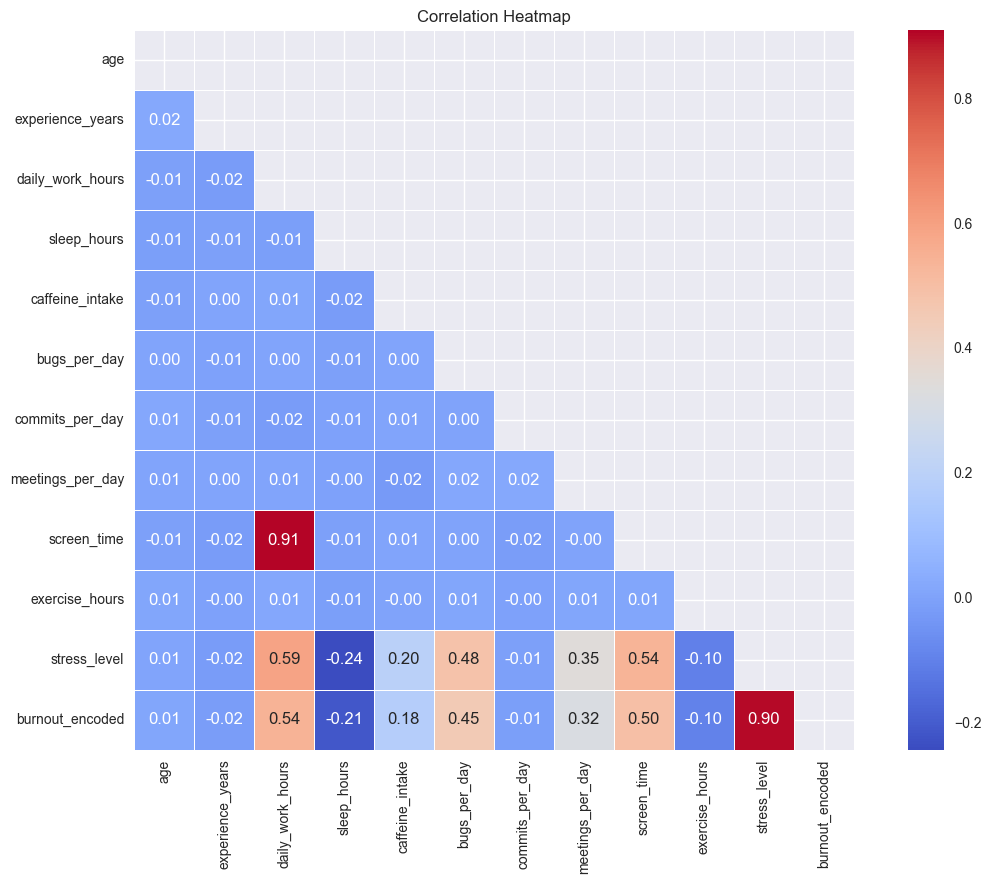

,correlation_with_burnout
stress_level,0.904308
daily_work_hours,0.541240
screen_time,0.495354
bugs_per_day,0.453431
meetings_per_day,0.316683
sleep_hours,-0.214480
caffeine_intake,0.178268
exercise_hours,-0.097418
experience_years,-0.018101
commits_per_day,-0.012110


In [46]:
num_cols_corr = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[num_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

if "burnout_encoded" in corr.columns:
    target_corr = corr["burnout_encoded"].drop("burnout_encoded").sort_values(key=lambda s: s.abs(), ascending=False)
    display(target_corr.to_frame("correlation_with_burnout"))

---
### Insight Korelasi

Pertanyaan yang kami ajukan: apakah ada fitur yang terlalu saling berkaitan? Dan fitur mana yang paling berkorelasi dengan target burnout?

**Temuan:**
- `stress_level`dan `burnout_encoded` = 0.90 memiliki korelasi tertinggi dengan target, jauh melampaui fitur lain
- `daily_work_hours` dan `screen_time` = 0.91 terjadi multikolinearitas antar fitur
- Sebagian besar korelasi antar fitur mendekati 0 sehingga fitur-fitur lain relatif independen satu sama lain

**Interpretasi:**

Multikolinearitas `daily_work_hours` dan `screen_time`:

Menurut kami dua fitur ini bercerita hal yang hampir sama dimana seorang developer yang kerja lama cenderung juga lama di depan layar. Untuk model berbasis koefisien seperti Logistic Regression, ini bisa membuat koefisien keduanya tidak stabil. Sehingga kami akan Drop `screen_time` ketika menggunakan model linear

Hubungan `stress_level` dengan targer:
- stress_level berkorelasi tinggi dengan target tapi menurut kami kurang relevan
- Tidak bisa diukur secara objektif di dunia nyata karena sangat subjektif
- Misalkan ada pertanyaan "Seberapa stress kamu?" menurut kami sama saja pertanyaannya dengan "Seberapa burnout kamu?"
- Model yang dibangun dengan `stress_level` tidak akan generalizable pada saat deployment


## 10. Analisis Bivariat (fitur dengan target)

Disini kami melakukan analisis bivariat dengan membandingkan distribusi tiap fitur di setiap kelas target. Dimana ini bisa menjawab:
- Fitur mana yang paling bisa membedakan kelas Low, Medium, High
- Apakah ada trend yang jelas antara nilai fitur dan tingkat burnout?

Visualisasi yang digunakan:
- Boxplot untuk melihat median, spread, dan outlier per kelas
- Violin plot untuk melihat distribusi penuh atau density per kelas
- Stacked bar untuk melihat proporsi burnout level per kelompok usia

/var/folders/m_/wtgtrqks5dsf4_g87mdf_ln80000gn/T/ipykernel_1731/2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
/var/folders/m_/wtgtrqks5dsf4_g87mdf_ln80000gn/T/ipykernel_1731/2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
/var/folders/m_/wtgtrqks5dsf4_g87mdf_ln80000gn/T/ipykernel_1731/2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
/var

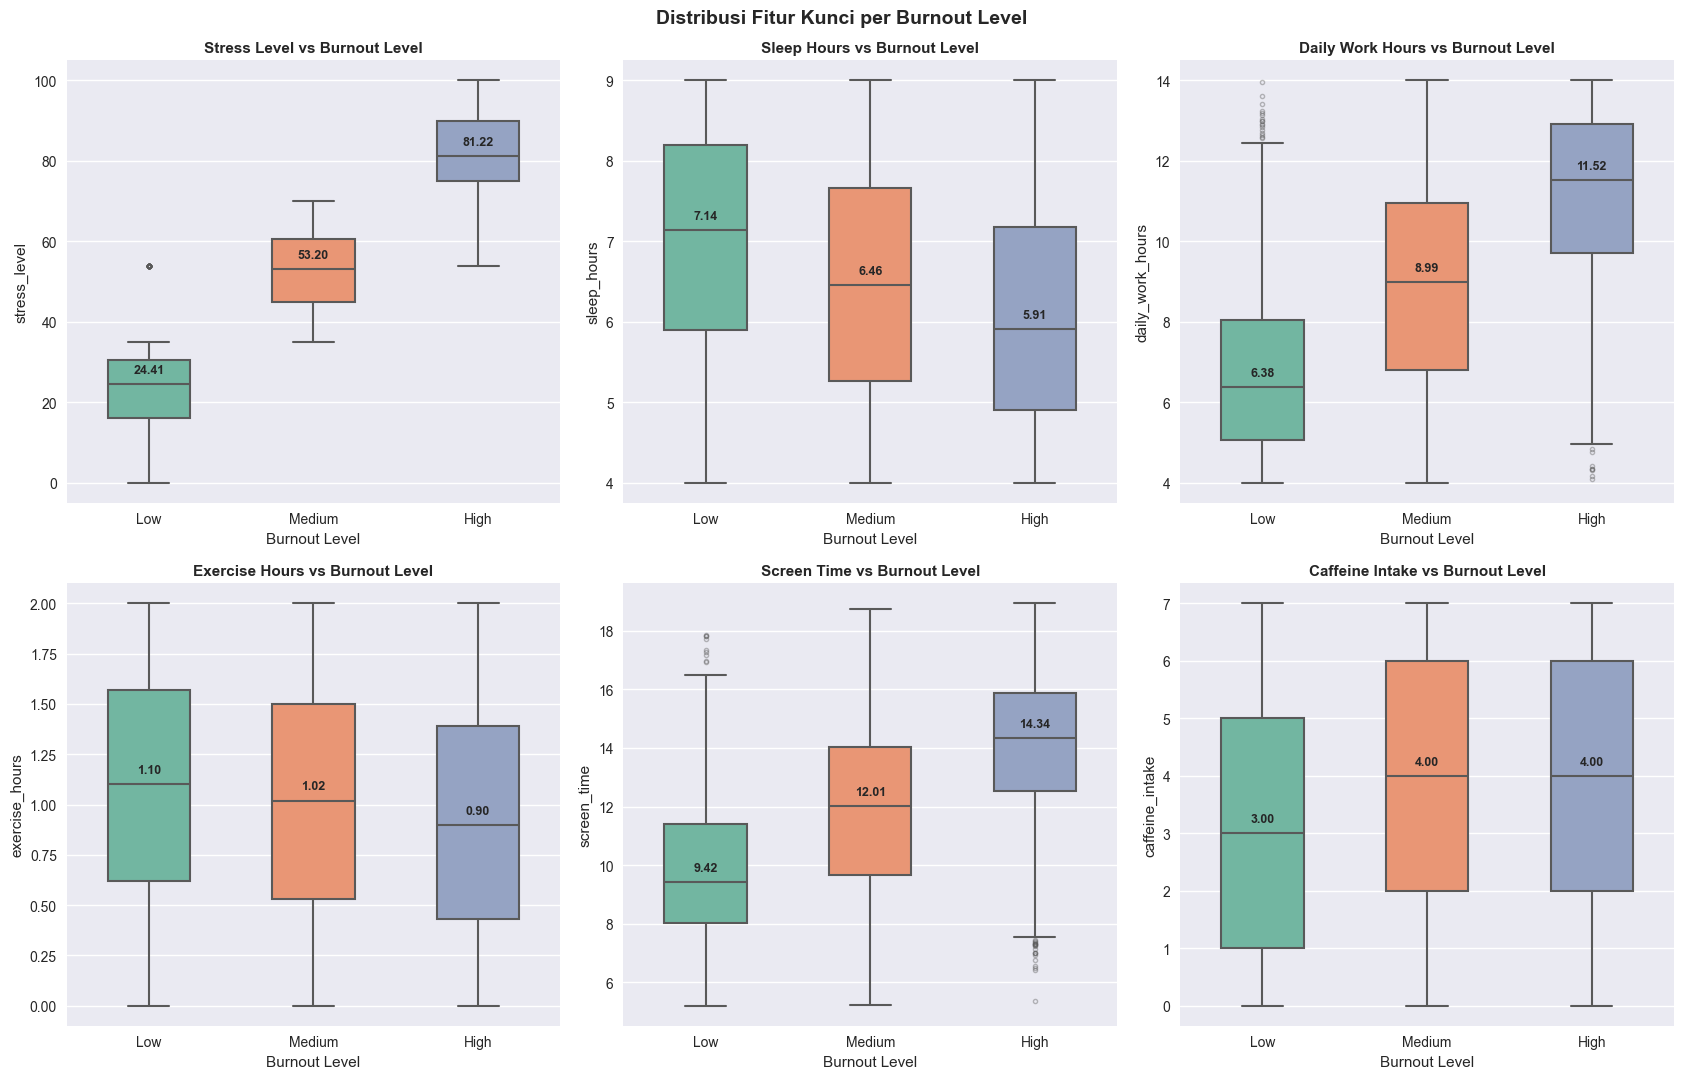

In [47]:
key_features = ['stress_level', 'sleep_hours', 'daily_work_hours',
                 'exercise_hours', 'screen_time', 'caffeine_intake']
order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
                ax=axes[i], palette='Set2', width=0.5, linewidth=1.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    medians = df_clean.groupby('burnout_level')[col].median()[order]
    for j, (lvl, med) in enumerate(medians.items()):
        axes[i].text(j, med + (df_clean[col].max() - df_clean[col].min()) * 0.02,
                     f'{med:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(f"{col.replace('_', ' ').title()} vs Burnout Level",
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Burnout Level')
    axes[i].set_ylabel(col)

plt.suptitle('Distribusi Fitur Kunci per Burnout Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/m_/wtgtrqks5dsf4_g87mdf_ln80000gn/T/ipykernel_1731/2873767090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='burnout_level', y='stress_level', data=df_clean,


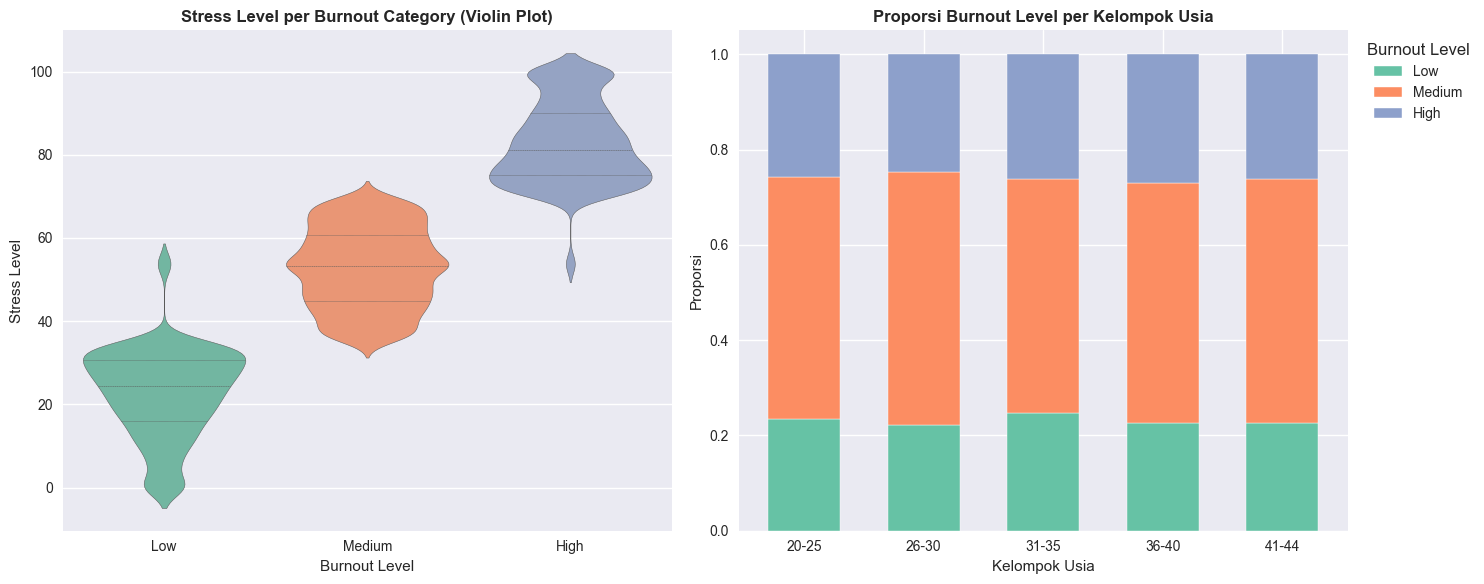

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(x='burnout_level', y='stress_level', data=df_clean,
               order=order, palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Stress Level per Burnout Category (Violin Plot)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Stress Level')

df_clean['age_group'] = pd.cut(df_clean['age'], bins=[19, 25, 30, 35, 40, 45],
                                labels=['20-25', '26-30', '31-35', '36-40', '41-44'])
age_burnout = (df_clean.groupby(['age_group', 'burnout_level'], observed=True)
               .size().unstack(fill_value=0)[order])
age_burnout_pct = age_burnout.div(age_burnout.sum(axis=1), axis=0)
age_burnout_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color=sns.color_palette('Set2', 3), edgecolor='white', width=0.6)
axes[1].set_title('Proporsi Burnout Level per Kelompok Usia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Proporsi')
axes[1].legend(title='Burnout Level', bbox_to_anchor=(1.01, 1))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [49]:
grouped_stats = df_clean.groupby(TARGET_COL)[numeric_cols].agg(["mean", "median"]).reindex(LABEL_ORDER)
display(grouped_stats)

age        experience_years        daily_work_hours  \
                    mean median             mean median             mean   
burnout_level                                                              
Low            32.044570   32.0         9.745763   10.0         6.741707   
Medium         32.092396   32.0         9.584505   10.0         8.924066   
High           32.278339   32.0         9.450617   10.0        11.125022   

                     sleep_hours        caffeine_intake        bugs_per_day  \
              median        mean median            mean median         mean   
burnout_level                                                                 
Low             6.38    6.972128   7.14        2.965474    3.0     5.812932   
Medium          8.99    6.461831   6.46        3.538881    4.0     9.226112   
High           11.52    6.093131   5.91        4.115600    4.0    13.168350   

                     commits_per_day        meetings_per_day         \
              median            mean median             mean median   
burnout_level                                                         
Low              5.0       14.670433   14.0         3.166353    3.0   
Medium           9.0       14.329412   14.0         4.592253    5.0   
High            14.0       14.363075   14.0         5.732323    6.0   

              screen_time         exercise_hours        stress_level         
                     mean  median           mean median         mean median  
burnout_level                                                                
Low              9.751030   9.420       1.084488   1.10    22.769209  24.41  
Medium          11.895928  12.010       1.012999   1.02    52.817871  53.20  
High            14.077138  14.335       0.926184   0.90    82.747065  81.22

---
### Insight Analisis Bivariat

**Pertanyaan yang kami ajukan:** Fitur mana yang paling mampu membedakan antara karyawan burnout rendah, sedang, dan tinggi?

**Temuan (diurutkan dari paling diskriminatif):**

1. **`stress_level`**: pemisahan kelas paling jelas, Namun fitur ini akan **di-drop dari modeling** karena menurut kami kurang relevan (lihat penjelasan di section berikutnya).
2. **`sleep_hours`** menunjukan tren negatif: makin sedikit tidur maka burnout makin tinggi.
3. **`daily_work_hours`** menunjukan tren positif: jam kerja panjang maka burnout lebih tinggi.
4. **`screen_time`** menunjukan tren positif sama sepertin `daily_work_hours`. Keduanya kami coba pertahankan karena secara konsep mengukur hal berbeda jam kerja tinggi tidak otomatis berarti screen time tinggi (seseorang bisa kerja sedikit tapi lama main HP), begitu pun sebaliknya.
5. **`exercise_hours`** menunjukan tren negatif: olahraga lebih banyak cenderung melindungi dari burnout tinggi.
6. **`caffeine_intake`** ada perbedaan antar kelas kecil dimana ada kemungkinan bukan fitur yang signifikan.
7. **`age_group`**: proporsi burnout merata di semua kelompok usia sehingga menurut kami usia bukan faktor pembeda utama.

**Interpretasi:**

Pola ini konsisten dengan teori burnout: *jam kerja panjang + tidur kurang + jarang olahraga → burnout tinggi*.
Namun bisa saja karyawan yang sudah burnout justru jadi tidur lebih sedikit (bukan sebaliknya), atau keduanya disebabkan faktor ketiga yang sama.

## 12. Feature Selection untuk Modeling

Pada final modeling, kami merancang untuk fitur yang digunakan adalah fitur numerik utama selain `stress_level`:
- `stress_level` terlalu dekat dengan konsep burnout, sehingga berpotensi menjadi leakage.
- `burnout_level` adalah target asli dan tidak boleh menjadi fitur.
- `burnout_encoded` hanya digunakan sebagai label numerik (target).

### Fitur Final untuk Modeling
`age`, `experience_years`, `daily_work_hours`, `screen_time`, `sleep_hours`, `exercise_hours` , `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day`, dan **target:**`burnout_encoded`

In [50]:
df_final = df_clean.drop(columns=[TARGET_COL, "stress_level"], errors="ignore")

print(f"Shape dataset final referensi: {df_final.shape}")
print(f"Kolom akhir: {df_final.columns.tolist()}")
display(df_final.head())

Shape dataset final referensi: (6860, 12)
Kolom akhir: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'burnout_encoded', 'age_group']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,burnout_encoded,age_group
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,1,26-30
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,2,36-40
2,34.0,13.0,8.99,4.03,5.0,2.0,18.0,9.0,11.18,1.54,1,31-35
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,1,26-30
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,0,26-30


## 13. Simpan Dataset Preprocessed Referensi

File `dataset_preprocessed.csv` disimpan untuk memudahkan inspeksi dan dokumentasi. Model final tetap membaca `dataset.csv` mentah agar preprocessing dilakukan secara benar di dalam pipeline training.

In [51]:
df_final.to_csv("dataset_preprocessed.csv", index=False)
print("dataset_preprocessed.csv berhasil disimpan.")

dataset_preprocessed.csv berhasil disimpan.


## 14. Ringkasan & Insight EDA

Ringkasan keputusan preprocessing:

| Langkah | Keputusan |
|---|---|
| Missing target | Dihapus karena target tidak boleh diimputasi |
| Missing fitur numerik | Median imputation untuk referensi; pipeline imputation untuk modeling final |
| Duplikasi | Tidak ditemukan |
| Outlier | Tidak ditemukan |
| Target encoding | Low=0, Medium=1, High=2 |
| `stress_level` | Dianalisis di EDA, tetapi dihapus dari final model untuk mengurangi leakage dan tidak bisa diukur secara objektif di dunia nyata|

### Key Findings dari EDA

1. **Distribusi kelas seimbang**
Medium (51.8%), High (25.5%), Low (22.8%). Accuracy valid sebagai metrik, F1-score per kelas tetap dipantau saat modeling.

2. **`stress_level` paling diskriminatif tapi di-drop** 
korelasi 0.90 dengan target dan tidak bisa diukur objektif

3. **`daily_work_hours` dan `screen_time`**
secara konsep mengukur hal berbeda; korelasi tinggi adalah artefak dataset synthetic. Untuk model linear, pertimbangkan drop `screen_time`.

4. **`sleep_hours` berkorelasi negatif dengan burnout** 
tidur cukup bersifat protektif terhadap burnout.

5. **`exercise_hours` juga protektif** 
olahraga lebih banyak cenderung menurunkan burnout.

6. **Tidak ada multikolinearitas parah antar fitur lain**
sebagian besar korelasi antar fitur mendekati 0, semua fitur membawa informasi yang relatif independen.

### Fitur Final (10 fitur + 1 target)
`age`, `experience_years`, `daily_work_hours`, `screen_time`, `sleep_hours`, `exercise_hours` , `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day`, dan **target:**`burnout_encoded`